In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from datetime import datetime
import datetime
import pandas as pd
import netCDF4 as nc
import glob # for using wildcards etc.
import cartopy.crs as ccrs
import cartopy.feature as feat
import cartopy
import pytz
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from matplotlib.transforms import offset_copy
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LongitudeLocator, LatitudeLocator

import matplotlib.ticker as mticker

from shapely.geometry.polygon import LinearRing
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
%matplotlib inline

In [2]:
style = "/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle"
plt.style.use(style)

Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 15 ("xtick.color: 'k'")
Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 16 ("ytick.color: 'k'")
Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 27 ('axes.edgecolor:222222')


In [3]:
def get_terrain_data(topography_file, projection, lonmin, lonmax, latmin, latmax, pad_deg=0.5):
    '''
    Load in the terrain data and convert the lon coordinates to projection coordinates
    '''
    #load in topo dataset and plot
    topods = nc.Dataset(topography_file)
    #these values need to be padded to avoid cutting off the terrain on the edges
    pad_deg = 0.5
    padlonmin = lonmin-pad_deg
    padlonmax = lonmax+pad_deg
    padlatmin = latmin-pad_deg
    padlatmax = latmax+pad_deg


    terlonmin = np.argmin(np.abs(np.array(topods.variables['x'])-(padlonmin)))
    terlonmax = np.argmin(np.abs(np.array(topods.variables['x'])-(padlonmax)))
    terlatmin = np.argmin(np.abs(np.array(topods.variables['y'])-(padlatmin)))
    terlatmax = np.argmin(np.abs(np.array(topods.variables['y'])-(padlatmax)))
    llon, llat = np.meshgrid(topods.variables['x'][terlonmin:terlonmax]
                             , topods.variables['y'][terlatmin:terlatmax])
    all_pts = projection.transform_points(ccrs.PlateCarree(), llon, llat)
    x = all_pts[:,:,0]
    y = all_pts[:,:,1]
    return x, y, np.array(topods.variables['z'][terlatmin:terlatmax, terlonmin:terlonmax])
def shiftedColorMap(cmap, start=0, midpoint=0.5, stop=1.0, name='shiftedcmap'):
    '''
    Function to offset the "center" of a colormap. Useful for
    data with a negative min and positive max and you want the
    middle of the colormap's dynamic range to be at zero

    Input
    -----
      cmap : The matplotlib colormap to be altered
      start : Offset from lowest point in the colormap's range.
          Defaults to 0.0 (no lower ofset). Should be between
          0.0 and `midpoint`.
      midpoint : The new center of the colormap. Defaults to 
          0.5 (no shift). Should be between 0.0 and 1.0. In
          general, this should be  1 - vmax/(vmax + abs(vmin))
          For example if your data range from -15.0 to +5.0 and
          you want the center of the colormap at 0.0, `midpoint`
          should be set to  1 - 5/(5 + 15)) or 0.75
      stop : Offset from highets point in the colormap's range.
          Defaults to 1.0 (no upper ofset). Should be between
          `midpoint` and 1.0.
    '''
    cdict = {
        'red': [],
        'green': [],
        'blue': [],
        'alpha': []
    }

    # regular index to compute the colors
    reg_index = np.linspace(start, stop, 257)

    # shifted index to match the data
    shift_index = np.hstack([
        np.linspace(0.0, midpoint, 128, endpoint=False), 
        np.linspace(midpoint, 1.0, 129, endpoint=True)
    ])

    for ri, si in zip(reg_index, shift_index):
        r, g, b, a = cmap(ri)

        cdict['red'].append((si, r, r))
        cdict['green'].append((si, g, g))
        cdict['blue'].append((si, b, b))
        cdict['alpha'].append((si, a, a))

    newcmap = matplotlib.colors.LinearSegmentedColormap(name, cdict)
    try:
        plt.cm.get_cmap(name)
    except ValueError:
        plt.register_cmap(cmap=newcmap)

    return newcmap
topography_file = '/Users/cneumaie/Downloads/map_topo_files/ETOPO1_Ice_g_gmt4.grd'

county_shapefile = '/Users/cneumaie/Downloads/map_topo_files/cb_2021_us_county_5m/cb_2021_us_county_5m.shp'
# CO roads shapefile
co_roads_shapefile = '/Users/cneumaie/Downloads/map_topo_files/tl_2021_08_prisecroads/tl_2021_08_prisecroads.shp'
# WY roads shapefile
wy_roads_shapefile = '/Users/cneumaie/Downloads/map_topo_files/tl_2021_56_prisecroads/tl_2021_56_prisecroads.shp'
# Weld county all roads
weld_roads_shapefile = '/Users/cneumaie/Downloads/map_topo_files/tl_2025_08123_roads/tl_2025_08123_roads.shp'
# NE roads shapefile
ne_roads_shapefile = '/Users/cneumaie/Downloads/map_topo_files/tl_2021_31_prisecroads/tl_2021_31_prisecroads.shp'
all_road_shapefiles = [co_roads_shapefile, wy_roads_shapefile, ne_roads_shapefile]


In [5]:

SGRC_lat = 40.809444
SGRC_lon = -104.777816
tower_lat = 40.815536
tower_lon = -104.74559

/var/folders/4q/by3lqw_x3cd0qthd139_q_zw000cm7/T/ipykernel_86555/2623732630.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap(name)
/Users/cneumaie/opt/miniconda3/envs/Chimney_paper/lib/python3.12/site-packages/cartopy/mpl/gridliner.py:475: UserWarning: The .ylabels_left attribute is deprecated. Please use .left_labels to toggle visibility instead.
  warnings.warn('The .ylabels_left attribute is deprecated. Please '
/Users/cneumaie/opt/miniconda3/envs/Chimney_paper/lib/python3.12/site-packages/cartopy/mpl/gridliner.py:463: UserWarning: The .xlabels_bottom attribute is deprecated. Please use .bottom_labels to toggle visibility instead.
  warnings.warn('The .xlabels_bottom attribute is deprecated. Please '
/Users/cneumaie/opt/miniconda3/envs/Chimney_paper/lib/python3.12/site-packages/cartopy/mpl/gri

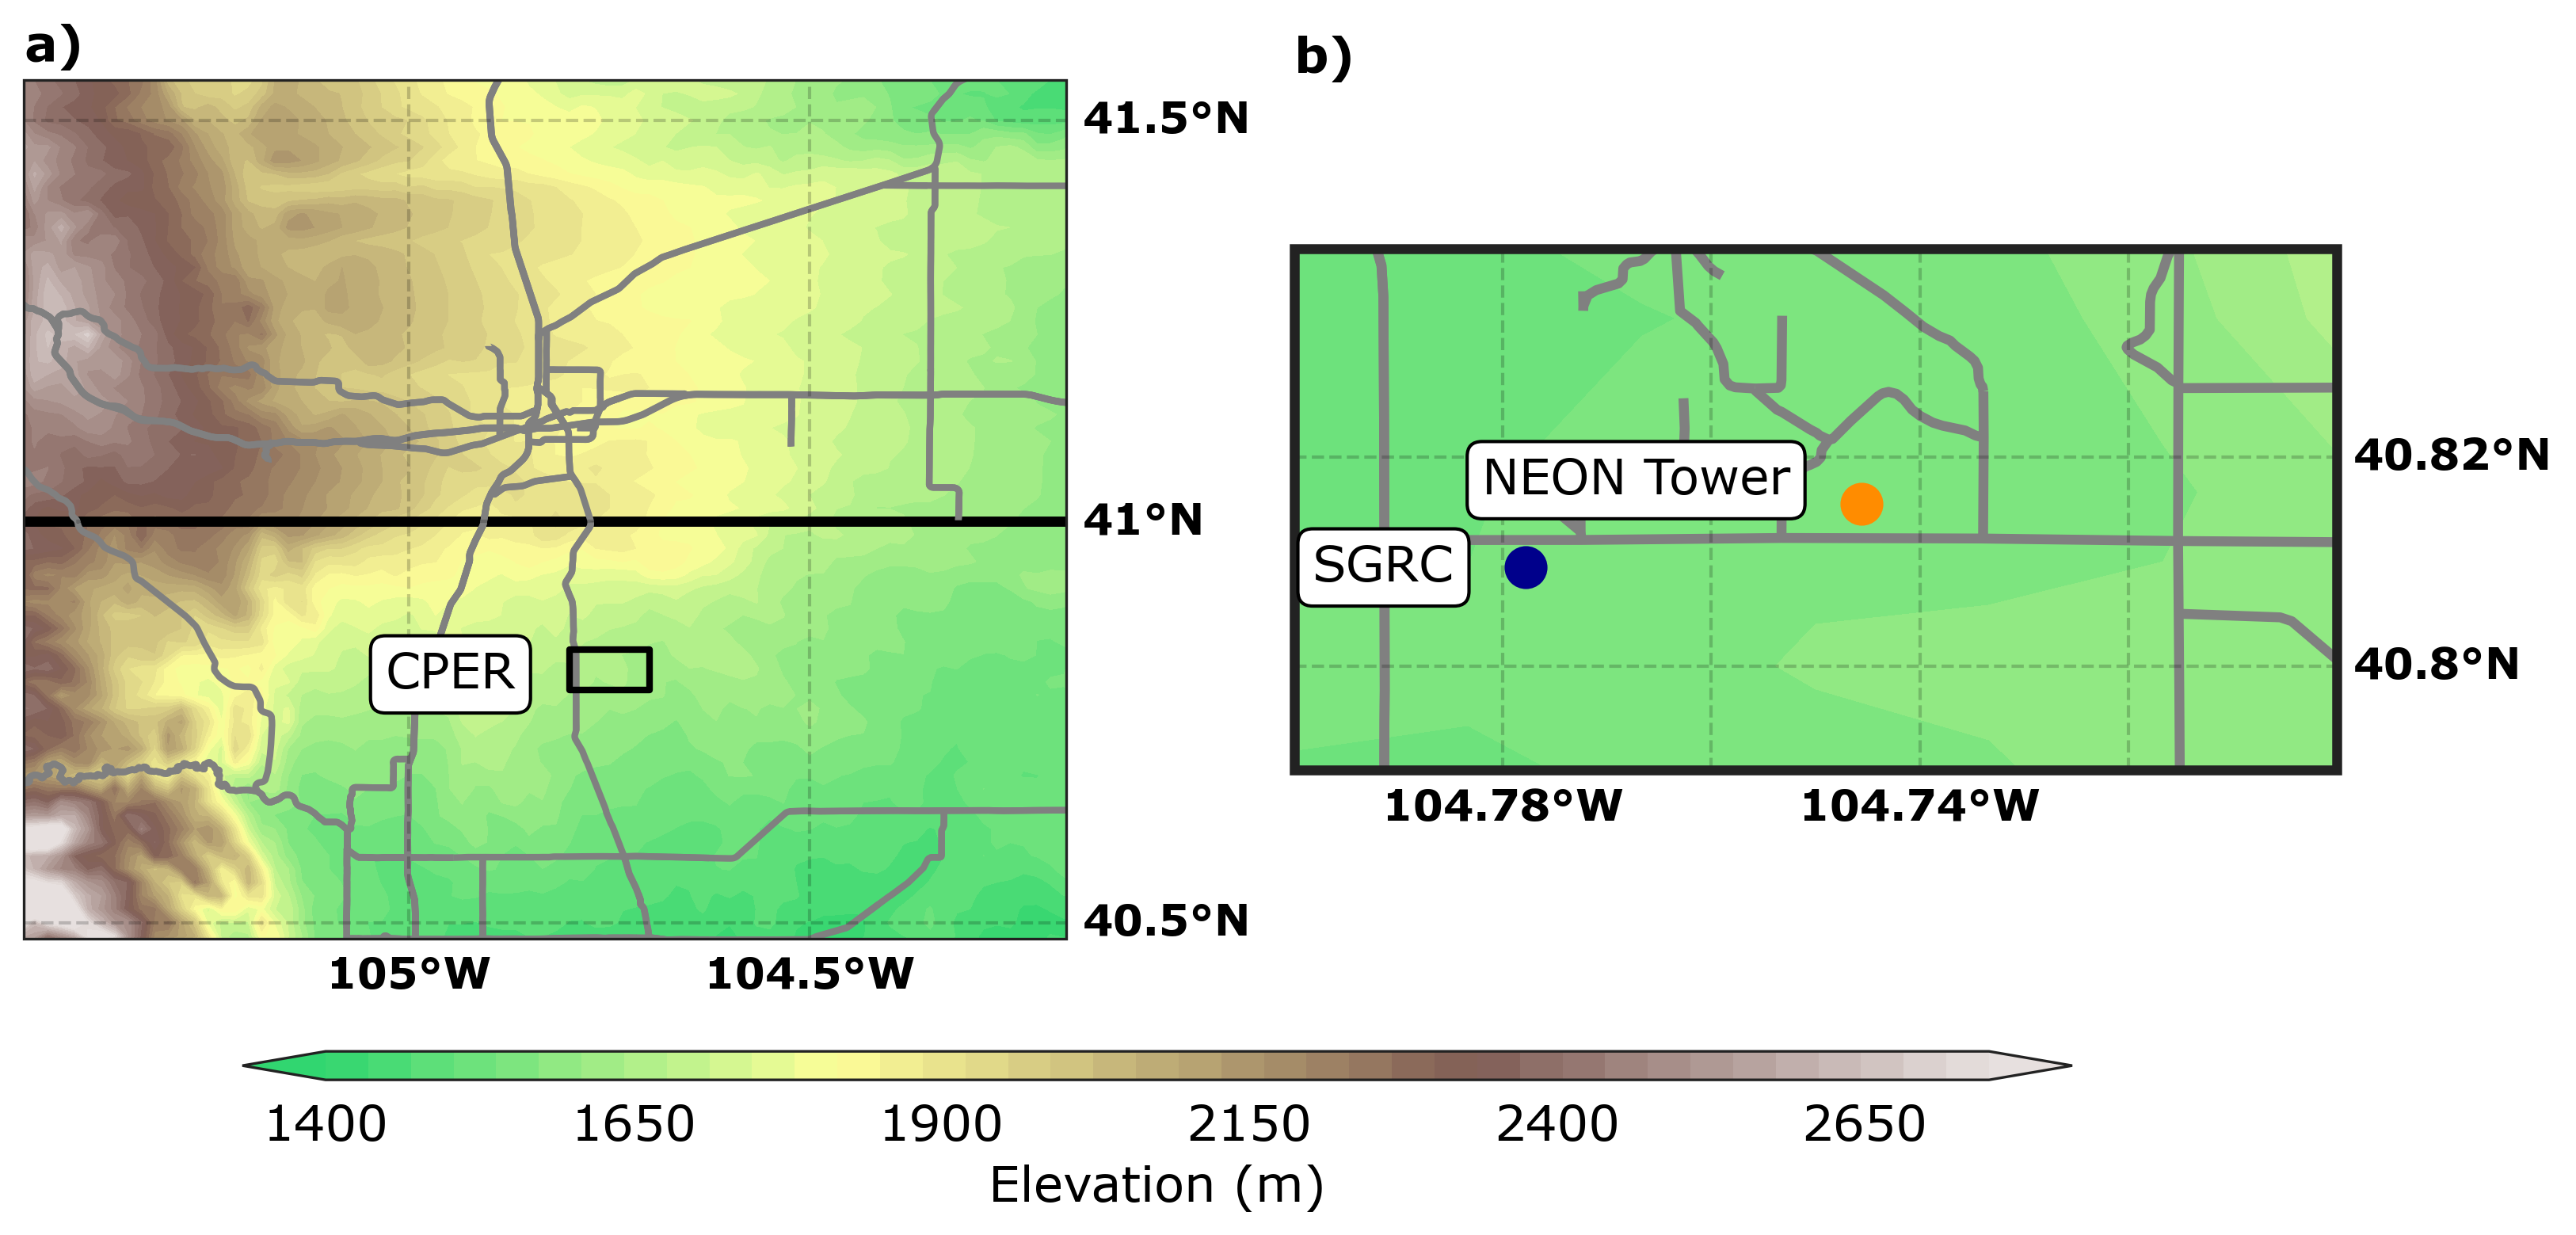

In [20]:

google_terrain = cimgt.GoogleTiles(style = "satellite")
fig = plt.figure(figsize = (11,6))
fsize = 15

lonmin = -105.48
lonmax = -104.18
latmin = 40.48
latmax = 41.55

lonmin2 = -104.8
lonmax2 = -104.7
latmin2 = 40.79
latmax2 = 40.84

proj = ccrs.PlateCarree(central_longitude=(lonmax-lonmin)/2)
terrain_x, terrain_y, terrain_data = get_terrain_data(topography_file, projection=proj,
                                        lonmin=lonmin, lonmax=lonmax, latmin=latmin, latmax=latmax)
terrain_data = {'x': terrain_x, 'y':terrain_y, 'z': terrain_data}

ax0 = fig.add_subplot(1, 2, 1, projection= proj)
ax0.set_extent([ lonmin, lonmax, latmin, latmax,])#, crs=ccrs.Geodetic())

proj = ccrs.PlateCarree(central_longitude=(lonmax-lonmin)/2)
terrain_x, terrain_y, terrain_data = get_terrain_data(topography_file, projection=proj,
                                        lonmin=lonmin, lonmax=lonmax, latmin=latmin, latmax=latmax)

terrain_data = {'x': terrain_x, 'y':terrain_y, 'z': terrain_data}
shrunk_cmap = shiftedColorMap(matplotlib.cm.terrain, start=0.3, midpoint=0.5, stop=0.95, name='shrunk_terrain')
tercont = ax0.contourf(terrain_data['x'], terrain_data['y'], terrain_data['z'], 
            levels=np.linspace(1400,2751,40), cmap=shrunk_cmap, zorder=0, extend='both',
            transform_first=True)
ax0.add_feature(cfeature.STATES, linewidth = 3)

roads = cartopy.io.shapereader.Reader(co_roads_shapefile)
roads_wy = cartopy.io.shapereader.Reader(wy_roads_shapefile)
roads_ne = cartopy.io.shapereader.Reader(ne_roads_shapefile)
ax0.add_geometries(roads.geometries(), ccrs.PlateCarree(),
                         edgecolor='grey', facecolor='None', linewidth=2)
ax0.add_geometries(roads_wy.geometries(), ccrs.PlateCarree(),
                         edgecolor='grey', facecolor='None', linewidth=2)
ax0.add_geometries(roads_ne.geometries(), ccrs.PlateCarree(),
                         edgecolor='grey', facecolor='None', linewidth=2)
# ax0.plot(SGRC_lon, SGRC_lat, marker='s', markersize = 5, color='k', alpha=1, transform=ccrs.PlateCarree(), zorder=10)
lons = [lonmin2, lonmax2, lonmax2, lonmin2, lonmin2]
lons = [lonmax2, lonmin2, lonmin2, lonmax2, lonmax2]
lons2 = [lonmax2,lonmax2,lonmin2,lonmin2]
lats2 = [latmin2,latmax2,latmax2,latmin2]
lats = [latmin2, latmin2, latmax2, latmax2, latmin2]
ring = LinearRing(list(zip(lons, lats)))
ax0.add_geometries([ring], ccrs.PlateCarree(), facecolor='none', edgecolor='k', linewidth =2)


ax0.set_title("a)", y = 1, fontsize = fsize)
geodetic_transform = ccrs.PlateCarree()._as_mpl_transform(ax0)

text_transform = offset_copy(geodetic_transform, units='dots', x=-90)

ax0.text(SGRC_lon, SGRC_lat, 'CPER',
        verticalalignment='center', horizontalalignment='right',
        transform=text_transform,
        bbox=dict(facecolor='white', alpha=1, boxstyle='round'),
                 fontsize = fsize, color="k")
gl = ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='k', alpha=0.2, linestyle='--')
gl.ylabels_left = False

gl.xlabels_bottom = True
gl.xlabels_top = False

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = mticker.MultipleLocator(0.5)
gl.ylocator = mticker.MultipleLocator(0.5)

gl.xlabel_style = {'size': fsize, 'color': 'gray'}
gl.xlabel_style = {'color': 'k', 'weight': 'bold', 'size': fsize-2}
gl.ylabel_style = {'size': fsize, 'color': 'gray'}
gl.ylabel_style = {'color': 'k', 'weight': 'bold', 'size': fsize-2}


lonmin = -104.8
lonmax = -104.7
latmin = 40.79
latmax = 40.84
proj = ccrs.PlateCarree(central_longitude=(lonmax-lonmin)/2)

ax = fig.add_subplot(1, 2, 2, projection= proj)

ax.set_extent([ lonmin, lonmax, latmin, latmax,])#, crs=ccrs.Geodetic())

shrunk_cmap = shiftedColorMap(matplotlib.cm.terrain, start=0.3, midpoint=0.5, stop=0.95, name='shrunk_terrain')



SGRC_lat = 40.809444
SGRC_lon = -104.777816
tower_lat = 40.815536
tower_lon = -104.74559

ax.plot(SGRC_lon, SGRC_lat, marker='o', markersize = 12, color='darkblue', alpha=1, transform=ccrs.PlateCarree(), zorder=10)
ax.plot(tower_lon, tower_lat, marker='o', markersize=12, color='darkorange', alpha=1, transform=ccrs.PlateCarree())

tercont = ax.contourf(terrain_data['x'], terrain_data['y'], terrain_data['z'], 
            levels=np.linspace(1400,2751,40), cmap=shrunk_cmap, zorder=0, extend='both',
            transform_first=True)
geodetic_transform = ccrs.PlateCarree()._as_mpl_transform(ax)

text_transform = offset_copy(geodetic_transform, units='dots', x=-90)
text_transform2 = offset_copy(geodetic_transform, units='dots', x=-90, y = 30)

ax.text(SGRC_lon, SGRC_lat, 'SGRC',
        verticalalignment='center', horizontalalignment='right',
        transform=text_transform,
        bbox=dict(facecolor='white', alpha=1, boxstyle='round'),
                 fontsize = fsize, color = 'k')
ax.text(tower_lon, tower_lat, 'NEON Tower',
        verticalalignment='center', horizontalalignment='right',
        transform=text_transform2,
        bbox=dict(facecolor='white', alpha=1, boxstyle='round'),
                 fontsize = fsize, color = 'k')
ax.set_title("b)", y =1.3, fontsize = fsize)

roads = cartopy.io.shapereader.Reader(weld_roads_shapefile)
ax.add_geometries(roads.geometries(), ccrs.PlateCarree(),
                         edgecolor='grey', facecolor='None', linewidth=3)


ax.tick_params(size = fsize-2)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='k', alpha=0.2, linestyle='--')

cbaxes = fig.add_axes([0.1, 0.1, 0.7, 0.02])   # This is the position for the colorbar

cbaxes.xaxis.set_ticks(np.arange(1400,2751,250))
cbaxes.xaxis.set_ticks_position('none')
cb.set_label('Elevation (m)', fontsize = fsize)
cb.ax.tick_params(labelsize=fsize)

gl.xlabels_top = False
gl.ylabels_left = False

gl.xlabels_bottom = True

gl.xlocator = mticker.MultipleLocator(0.02)
gl.ylocator = mticker.MultipleLocator(0.02)

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

gl.xlabel_style = {'size': fsize, 'color': 'gray'}
gl.xlabel_style = {'color': 'k', 'weight': 'bold', 'size': fsize-2}
gl.ylabel_style = {'size': fsize, 'color': 'gray'}
gl.ylabel_style = {'color': 'k', 'weight': 'bold', 'size': fsize-2}

for location in ["geo"]:
    ax.spines[location].set_linewidth(3)

plt.savefig("fig1_ab_08142026", dpi = 600)
plt.show()
plt.close()